# Лабораторная 5 — Детекция номеров на изображениях

## 1. Импорты и настройка

In [1]:
import os, random, tarfile, urllib.request, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import h5py
from PIL import Image

import torch
import torch.utils.data as data
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, FasterRCNN_MobileNet_V3_Large_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}, Torchvision: {torchvision.__version__}')

Device: cuda
PyTorch: 2.9.0+cu128, Torchvision: 0.24.0+cu128


## 2. Скачивание SVHN (Format 2)

In [2]:
DATA_DIR = 'DATA/SVHN'
os.makedirs(DATA_DIR, exist_ok=True)

urls = {
    'train': 'http://ufldl.stanford.edu/housenumbers/train.tar.gz',
    'test':  'http://ufldl.stanford.edu/housenumbers/test.tar.gz',
}

for split, url in urls.items():
    tar_path = os.path.join(DATA_DIR, f'{split}.tar.gz')
    extract_dir = os.path.join(DATA_DIR, split)
    
    if os.path.exists(extract_dir) and os.path.exists(os.path.join(extract_dir, 'digitStruct.mat')):
        print(f'{split} уже скачан и распакован')
        continue
    
    if not os.path.exists(tar_path):
        print(f'Скачиваем {split}...')
        urllib.request.urlretrieve(url, tar_path)
        print(f'  Скачано: {os.path.getsize(tar_path) / 1e6:.0f} MB')
    
    print(f'Распаковываем {split}...')
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(DATA_DIR)
    print(f'  Готово: {extract_dir}')

train уже скачан и распакован
test уже скачан и распакован


## 3. Парсинг аннотаций из digitStruct.mat

In [ ]:
def parse_svhn_mat(mat_path):
    annotations = []
    
    with h5py.File(mat_path, 'r') as f:
        names_ds = f['digitStruct']['name']
        bboxes_ds = f['digitStruct']['bbox']
        n = names_ds.shape[0]
        
        for i in range(n):
            name_ref = names_ds[i][0]
            filename = ''.join(chr(c[0]) for c in f[name_ref][:])
            
            bbox_ref = bboxes_ds[i][0]
            bbox_obj = f[bbox_ref]
            
            attrs = {}
            for key in ['height', 'left', 'top', 'width', 'label']:
                attr_data = bbox_obj[key]
                if attr_data.shape[0] == 1:
                    attrs[key] = [float(attr_data[0, 0])]
                else:
                    attrs[key] = [
                        float(f[attr_data[j, 0]][()].flatten()[0])
                        for j in range(attr_data.shape[0])
                    ]
            
            x1 = min(attrs['left'])
            y1 = min(attrs['top'])
            x2 = max(l + w for l, w in zip(attrs['left'], attrs['width']))
            y2 = max(t + h for t, h in zip(attrs['top'], attrs['height']))
            
            annotations.append({
                'filename': filename,
                'bbox': [x1, y1, x2, y2],
                'n_digits': len(attrs['label'])
            })
            
            if (i + 1) % 5000 == 0:
                print(f'  Обработано {i+1}/{n}')
    
    print(f'Всего: {len(annotations)} изображений')
    return annotations

print('Парсим train аннотации...')
train_ann = parse_svhn_mat(os.path.join(DATA_DIR, 'train', 'digitStruct.mat'))

print('\nПарсим test аннотации...')
test_ann = parse_svhn_mat(os.path.join(DATA_DIR, 'test', 'digitStruct.mat'))

Парсим train аннотации...
  Обработано 5000/33402
  Обработано 10000/33402
  Обработано 15000/33402
  Обработано 20000/33402
  Обработано 25000/33402
  Обработано 30000/33402
Всего: 33402 изображений

Парсим test аннотации...
  Обработано 5000/13068
  Обработано 10000/13068
Всего: 13068 изображений


## 4. Визуализация данных

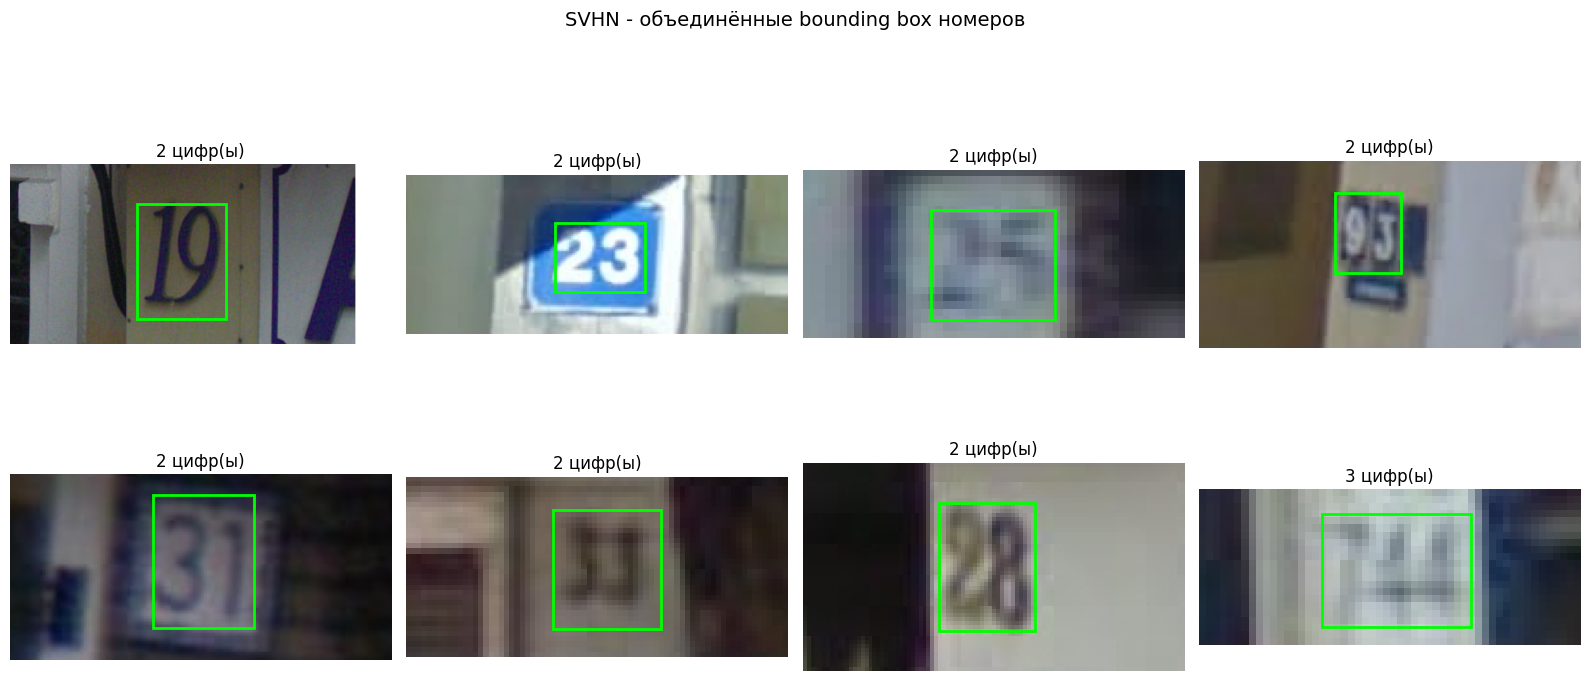

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, ax in enumerate(axes.flat):
    ann = train_ann[idx]
    img_path = os.path.join(DATA_DIR, 'train', ann['filename'])
    img = Image.open(img_path)
    ax.imshow(img)
    
    x1, y1, x2, y2 = ann['bbox']
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)
    ax.set_title(f"{ann['n_digits']} цифр(ы)")
    ax.axis('off')

plt.suptitle('SVHN - объединённые bounding box номеров', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Dataset и DataLoader

In [ ]:
IMG_SIZE = 128  

class SVHNDetectionDataset(data.Dataset):

    def __init__(self, annotations, img_dir, img_size=128, max_samples=None):
        self.img_dir = img_dir
        self.img_size = img_size
        self.annotations = annotations[:max_samples] if max_samples else annotations

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_path = os.path.join(self.img_dir, ann['filename'])
        img = Image.open(img_path).convert('RGB')
        orig_w, orig_h = img.size

        scale_x = self.img_size / orig_w
        scale_y = self.img_size / orig_h
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img_tensor = transforms.ToTensor()(img)

        x1, y1, x2, y2 = ann['bbox']
        x1 = max(0.0, x1 * scale_x)
        y1 = max(0.0, y1 * scale_y)
        x2 = min(float(self.img_size), x2 * scale_x)
        y2 = min(float(self.img_size), y2 * scale_y)
        x2 = max(x1 + 1, x2)
        y2 = max(y1 + 1, y2)

        target = {
            'boxes':  torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32),
            'labels': torch.tensor([1], dtype=torch.int64),
        }
        return img_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


MAX_TRAIN = 5000
MAX_TEST  = 2000

train_dataset = SVHNDetectionDataset(
    train_ann, os.path.join(DATA_DIR, 'train'), img_size=IMG_SIZE, max_samples=MAX_TRAIN
)
test_dataset = SVHNDetectionDataset(
    test_ann, os.path.join(DATA_DIR, 'test'), img_size=IMG_SIZE, max_samples=MAX_TEST
)

train_loader = data.DataLoader(
    train_dataset, batch_size=8, shuffle=True,
    collate_fn=collate_fn, num_workers=0
)
test_loader = data.DataLoader(
    test_dataset, batch_size=8, shuffle=False,
    collate_fn=collate_fn, num_workers=0
)

print(f'Train: {len(train_dataset)} ({len(train_loader)} батчей)')
print(f'Test:  {len(test_dataset)} ({len(test_loader)} батчей)')

Train: 5000 (625 батчей)
Test:  2000 (250 батчей)


## 6. Модель: Faster R-CNN (MobileNet V3)

In [ ]:
def get_detection_model(num_classes=2):
    model = fasterrcnn_mobilenet_v3_large_fpn(
        weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT,
        min_size=128,   
        max_size=256,   
    )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

model = get_detection_model(num_classes=2)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметры: {total_params:,} всего, {trainable_params:,} обучаемых')

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to C:\Users\valer/.cache\torch\hub\checkpoints\fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


100%|██████████| 74.2M/74.2M [00:07<00:00, 10.8MB/s]


Параметры: 18,930,229 всего, 18,871,333 обучаемых


## 7. Обучение

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    
    for i, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        
        if (i + 1) % 500 == 0:
            print(f'  batch {i+1}/{len(loader)}, loss: {losses.item():.4f}')
    
    return total_loss / len(loader)

In [10]:
NUM_EPOCHS = 7

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

history = {'train_loss': []}

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    loss = train_one_epoch(model, train_loader, optimizer, device)
    lr_scheduler.step()
    elapsed = time.time() - t0

    history['train_loss'].append(loss)
    lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Loss: {loss:.4f}, LR: {lr:.6f}, Time: {elapsed:.0f}s')

print('\nОбучение завершено!')

  batch 500/625, loss: 1.1397
Epoch 1/7 — Loss: 1.4938, LR: 0.005000, Time: 185s
  batch 500/625, loss: 1.4604
Epoch 2/7 — Loss: 1.4890, LR: 0.005000, Time: 65s
  batch 500/625, loss: 1.3283
Epoch 3/7 — Loss: 1.4499, LR: 0.002500, Time: 64s
  batch 500/625, loss: 1.4558
Epoch 4/7 — Loss: 1.3475, LR: 0.002500, Time: 64s
  batch 500/625, loss: 1.0178
Epoch 5/7 — Loss: 1.2996, LR: 0.002500, Time: 64s
  batch 500/625, loss: 1.4259
Epoch 6/7 — Loss: 1.2804, LR: 0.001250, Time: 64s
  batch 500/625, loss: 1.3531
Epoch 7/7 — Loss: 1.1902, LR: 0.001250, Time: 63s

Обучение завершено!


### График функции потерь

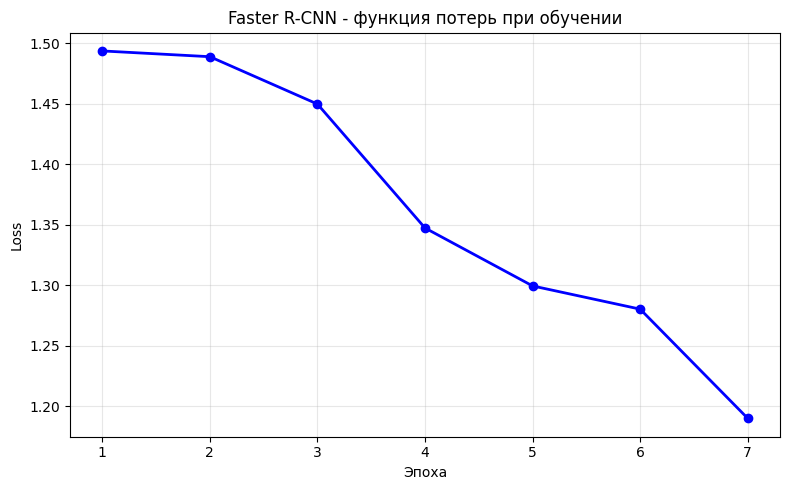

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS + 1), history['train_loss'], 'b-o', linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Faster R-CNN - функция потерь при обучении')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Оценка качества детекции

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    
    return inter / union if union > 0 else 0.0


def evaluate_detection(model, loader, device, iou_threshold=0.5, score_threshold=0.3):
    model.eval()
    
    all_scores = []
    all_matches = []  
    total_gt = 0
    all_ious = []
    
    with torch.no_grad():
        for i, (images, targets) in enumerate(loader):
            images = [img.to(device) for img in images]
            predictions = model(images)
            
            for pred, target in zip(predictions, targets):
                gt_boxes = target['boxes'].numpy()
                total_gt += len(gt_boxes)
                
                pred_boxes  = pred['boxes'].cpu().numpy()
                pred_scores = pred['scores'].cpu().numpy()
                
                mask = pred_scores >= score_threshold
                pred_boxes  = pred_boxes[mask]
                pred_scores = pred_scores[mask]
                
                matched_gt = set()
                for pb, ps in zip(pred_boxes, pred_scores):
                    best_iou = 0
                    best_gt_idx = -1
                    for gi, gb in enumerate(gt_boxes):
                        iou_val = compute_iou(pb, gb)
                        if iou_val > best_iou and gi not in matched_gt:
                            best_iou = iou_val
                            best_gt_idx = gi
                    
                    all_scores.append(ps)
                    if best_iou >= iou_threshold:
                        all_matches.append(True)
                        matched_gt.add(best_gt_idx)
                        all_ious.append(best_iou)
                    else:
                        all_matches.append(False)
            
            if (i + 1) % 200 == 0:
                print(f'  Evaluated {i+1}/{len(loader)} batches')
    
    sorted_idx = np.argsort(-np.array(all_scores))
    all_matches = np.array(all_matches)[sorted_idx]
    
    tp_cum = np.cumsum(all_matches)
    fp_cum = np.cumsum(~all_matches)
    
    precisions = tp_cum / (tp_cum + fp_cum)
    recalls = tp_cum / total_gt
    
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    
    for j in range(len(mpre) - 1, 0, -1):
        mpre[j - 1] = max(mpre[j - 1], mpre[j])
    
    change_points = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[change_points + 1] - mrec[change_points]) * mpre[change_points + 1])
    
    tp = all_matches.sum()
    fp = (~all_matches).sum()
    fn = total_gt - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    mean_iou  = np.mean(all_ious) if all_ious else 0
    
    return {
        'mAP': ap,
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'precisions': precisions,
        'recalls': recalls,
        'total_gt': total_gt,
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn)
    }

In [13]:
print('Оценка на тестовой выборке...')
results = evaluate_detection(model, test_loader, device)

print(f"\n{'='*45}")
print(f"  Mean IoU:    {results['mean_iou']:.4f}")
print(f"  Precision:   {results['precision']:.4f}")
print(f"  Recall:      {results['recall']:.4f}")
print(f"  mAP@0.5:     {results['mAP']:.4f}")
print(f"{'='*45}")
print(f"  TP={results['tp']}, FP={results['fp']}, FN={results['fn']}, GT={results['total_gt']}")

Оценка на тестовой выборке...
  Evaluated 200/250 batches

  Mean IoU:    0.7325
  Precision:   0.6955
  Recall:      0.7675
  mAP@0.5:     0.6933
  TP=1535, FP=672, FN=465, GT=2000


### Precision-Recall кривая

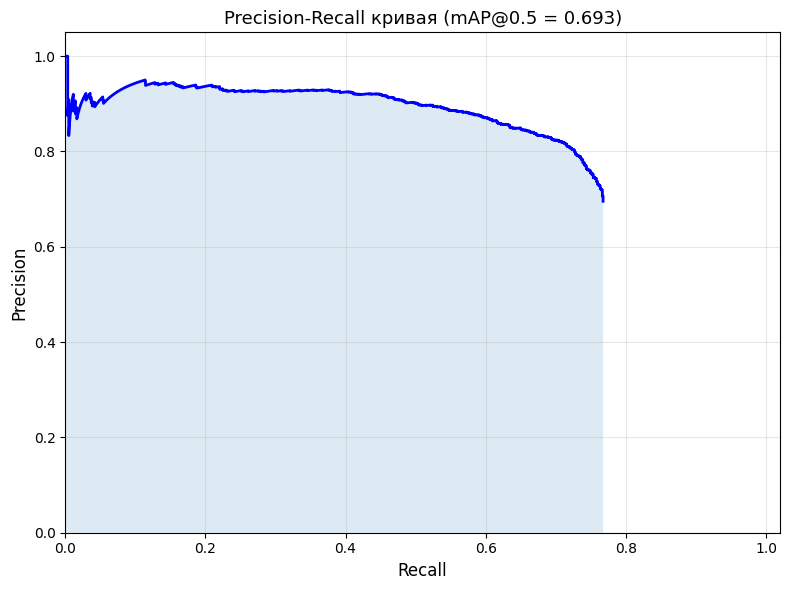

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(results['recalls'], results['precisions'], 'b-', linewidth=2)
plt.fill_between(results['recalls'], results['precisions'], alpha=0.15)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title(f"Precision-Recall кривая (mAP@0.5 = {results['mAP']:.3f})", fontsize=13)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1.02])
plt.ylim([0, 1.05])
plt.tight_layout()
plt.show()

## 9. Визуализация предсказаний на тестовых изображениях

- **Зелёный** пунктир — истинный bbox (ground truth)
- **Красный** — предсказание модели (с confidence score)

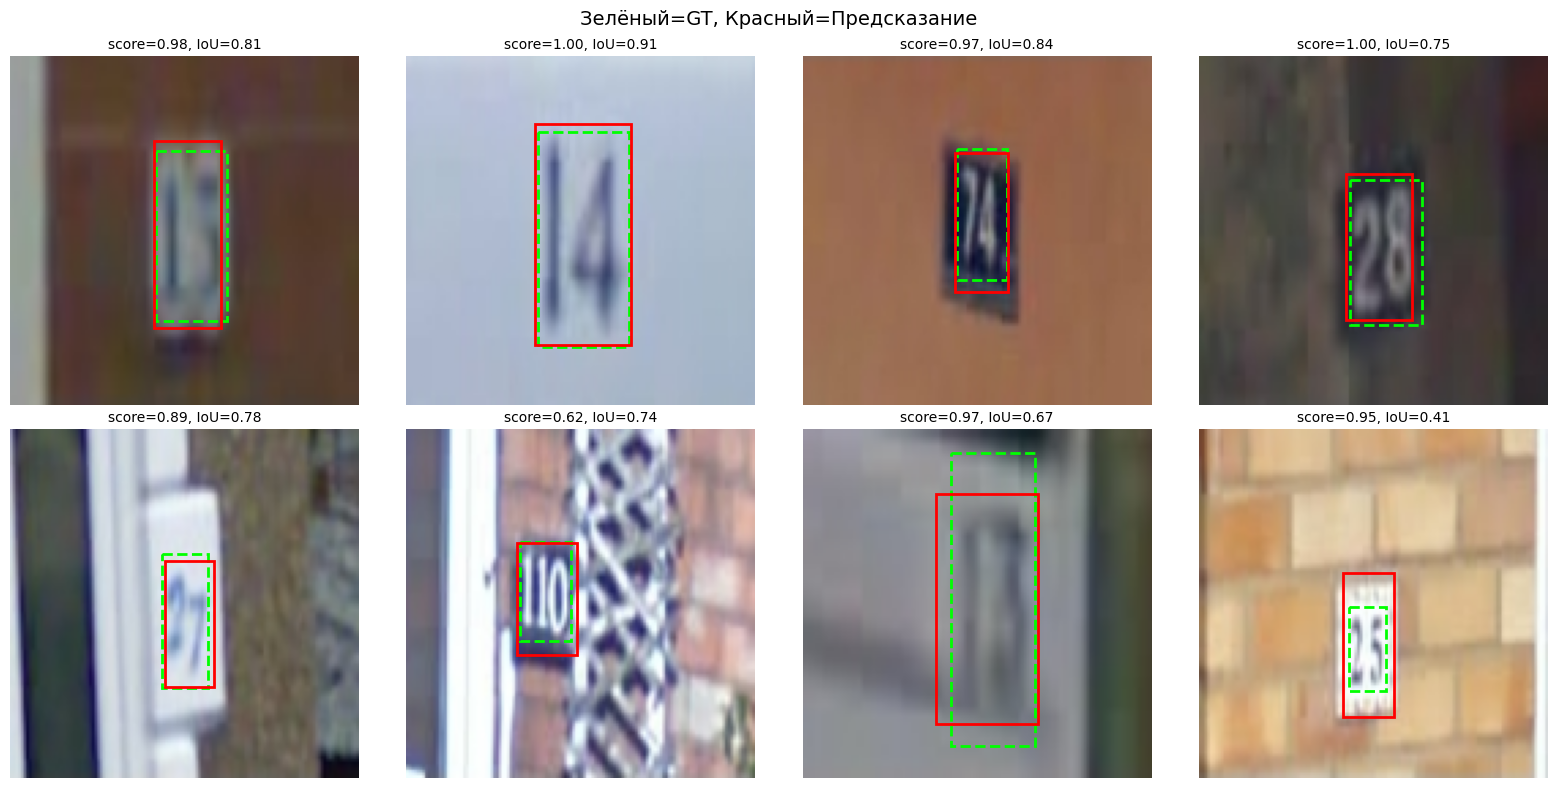

In [ ]:
model.eval()
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

random.seed(42)
sample_indices = random.sample(range(len(test_dataset)), 8)

for ax, idx in zip(axes.flat, sample_indices):
    img_tensor, target = test_dataset[idx]
    
    with torch.no_grad():
        pred = model([img_tensor.to(device)])[0]
    
    img_np = img_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    
    gt = target['boxes'][0].numpy()
    rect_gt = patches.Rectangle(
        (gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1],
        linewidth=2, edgecolor='lime', facecolor='none', linestyle='--'
    )
    ax.add_patch(rect_gt)
    
    if len(pred['boxes']) > 0 and pred['scores'][0].item() > 0.3:
        pb = pred['boxes'][0].cpu().numpy()
        score = pred['scores'][0].cpu().item()
        rect_pred = patches.Rectangle(
            (pb[0], pb[1]), pb[2]-pb[0], pb[3]-pb[1],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect_pred)
        
        iou = compute_iou(pb, gt)
        ax.set_title(f'score={score:.2f}, IoU={iou:.2f}', fontsize=10)
    else:
        ax.set_title('Нет детекции', fontsize=10)
    
    ax.axis('off')

plt.suptitle('Зелёный=GT, Красный=Предсказание', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Тестирование на собственных фотографиях

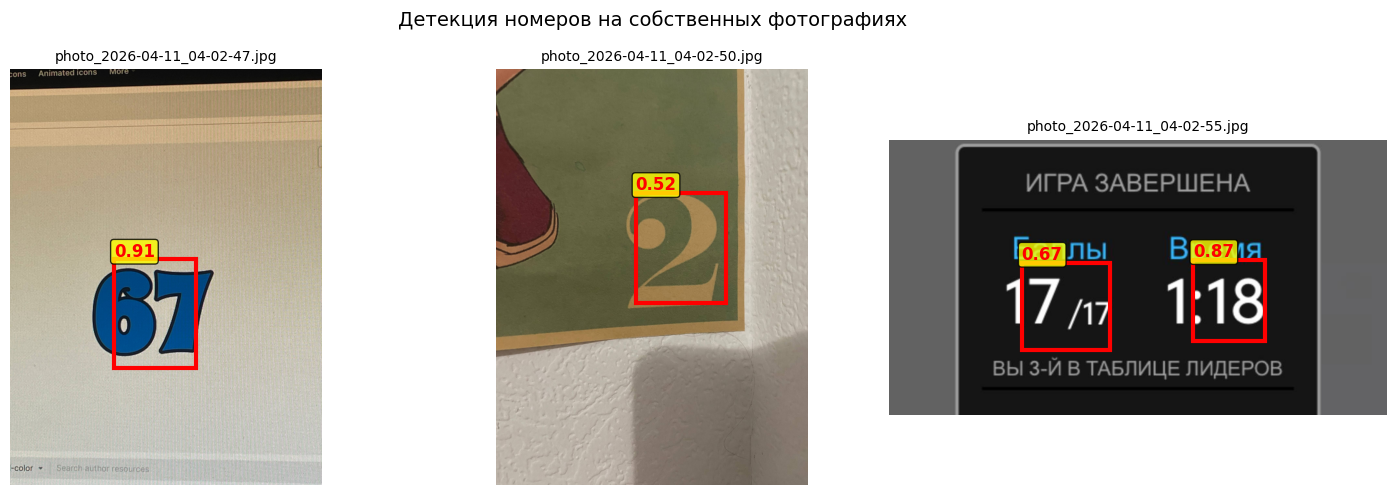

In [21]:
CUSTOM_DIR = os.path.join(DATA_DIR, 'custom')
os.makedirs(CUSTOM_DIR, exist_ok=True)

custom_images = [
    f for f in os.listdir(CUSTOM_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
]

if custom_images:
    model.eval()
    n_show = min(len(custom_images), 6)
    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]
    
    for ax, fname in zip(axes, custom_images[:n_show]):
        img = Image.open(os.path.join(CUSTOM_DIR, fname)).convert('RGB')
        
        max_side = 800
        if max(img.size) > max_side:
            ratio = max_side / max(img.size)
            new_size = (int(img.size[0] * ratio), int(img.size[1] * ratio))
            img = img.resize(new_size, Image.LANCZOS)
        
        img_tensor = transforms.ToTensor()(img)
        
        with torch.no_grad():
            pred = model([img_tensor.to(device)])[0]
        
        ax.imshow(img)
        
        for box, score in zip(pred['boxes'].cpu(), pred['scores'].cpu()):
            if score > 0.5:
                b = box.numpy()
                rect = patches.Rectangle(
                    (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                    linewidth=3, edgecolor='red', facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(
                    b[0], b[1] - 5, f'{score:.2f}',
                    color='red', fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.8)
                )
        
        ax.set_title(fname, fontsize=10)
        ax.axis('off')
    
    plt.suptitle('Детекция номеров на собственных фотографиях', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('Поместите свои фотографии в папку DATA/SVHN/custom/ и перезапустите ячейку')
    print(f'Путь: {os.path.abspath(CUSTOM_DIR)}')

---

## Выводы

**Модель:** Faster R-CNN (MobileNet V3 Large + FPN), предобученная на COCO, дообученная на SVHN.

**Результаты на тестовой выборке (2000 изображений):**

| Метрика | Значение |
|---|---|
| Mean IoU | 0.7325 |
| Precision | 0.6955 |
| Recall | 0.7675 |
| **mAP@0.5** | **0.6933** |

Требование mAP ≥ 0.6 **выполнено** (0.69 > 0.60).

### Анализ метрик

- **Mean IoU = 0.73** - предсказанные bbox хорошо совпадают с истинными (среднее перекрытие 73%)
- **Precision = 0.70** - из всех предсказаний ~70% действительно содержат номер, 30% — ложные срабатывания (FP=672)
- **Recall = 0.77** - модель находит 77% всех номеров, пропуская 23% (FN=465)
- **mAP = 0.69** - площадь под PR-кривой, учитывающая баланс precision/recall при разных порогах confidence